# Multi-region, multi-patch and latitude validation

This notebook provides the statistically powered synthetic validation requested
during co-author review. It is deliberately independent of
`test-resample-paper.ipynb`: every helper needed for coordinate-based synthesis,
PSF-aware reconstruction, aggregation, checkpointing, and uncertainty estimates
is defined here.

## Experimental unit and sampling hierarchy

- **Four scene classes:** urban, water, forest, and agriculture.
- **Ten geographically independent regions per class.** Regions span both
  hemispheres and a broad latitude range.
- **Nine non-overlapping 2.56 km × 2.56 km patches per region**, placed on a
  deterministic 3 × 3 grid with 4 km centre spacing.
- **360 patches total.** The nine patches within a region are treated as
  correlated subsamples, not nine independent replicates.
- Confidence intervals are therefore obtained by resampling **regions**, not
  individual patches (cluster bootstrap).

The coordinate manifest is displayed before any remote tile is requested.
Review it carefully and set `SITES_APPROVED = True` only after accepting the
sites. The full experiment is also disabled by default.

## Primary estimand

The target is the average latent, no-PSF value over each HEALPix cell. All
methods are evaluated on the same cell-average support. The primary metric is
RMSE against this latent reference. Recovery is reported relative to the
degradation introduced by the known Gaussian detector PSF:

\[
R = 1 - \frac{\mathrm{RMSE}(\widehat{x},x_0)}
               {\mathrm{RMSE}(x_{\mathrm{blur}},x_0)}.
\]

Positive values indicate recovery beyond the blurred observation; negative
values indicate additional degradation.

In [1]:
from __future__ import annotations

import gc
import hashlib
import io
import json
import math
import os
import platform
import shutil
import threading
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyproj
import requests
import scipy
import torch
import zarr
from PIL import Image
from scipy.interpolate import RegularGridInterpolator, griddata
from scipy.ndimage import gaussian_filter

try:
    import psutil
except ImportError:
    psutil = None

import healpy as hp
import healpix_resample
from healpix_resample import PSFResampler, fwhm_to_scale, recommend_npt


def locate_notebook_dir() -> Path:
    '''Work both from the repository root and from `notebooks/`.'''
    here = Path.cwd().resolve()
    if here.name.lower() == "notebooks":
        return here
    candidate = here / "notebooks"
    if candidate.is_dir():
        return candidate
    raise RuntimeError(
        "Run this notebook from the healpix-resample repository root "
        "or from its notebooks directory."
    )


NOTEBOOK_DIR = locate_notebook_dir()
DATA_DIR = NOTEBOOK_DIR / "data" / "multi_patch_latitude"
CACHE_DIR = DATA_DIR / "patch_cache"
ESRI_PATCH_CACHE_DIR = DATA_DIR / "esri_patch_cache"
TILE_CACHE_DIR = DATA_DIR / "esri_tile_cache"
TABLE_DIR = NOTEBOOK_DIR / "tables"
FIGURE_DIR = NOTEBOOK_DIR / "figures"
for directory in (
    DATA_DIR, CACHE_DIR, ESRI_PATCH_CACHE_DIR, TILE_CACHE_DIR, TABLE_DIR, FIGURE_DIR
):
    directory.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 20260818
HEALPIX_LEVEL = 20
PATCH_SIZE = 256
DETECTOR_GSD_M = 10.0
OVERSAMPLE = 4
TRUE_FWHM_M = 12.5
OPERATOR_FWHM = {
    "psf_aware_matched": TRUE_FWHM_M,
    "psf_aware_plus50": 1.5 * TRUE_FWHM_M,
    "psf_aware_minus50": 0.5 * TRUE_FWHM_M,
}
LAMBDA = 1.0e-3
MAX_ITER = 14
THRESHOLD = 0.1
TARGET_KERNEL_MASS = 0.99
ESRI_ZOOM = 17
PATCH_CENTRE_SPACING_M = 4000.0
DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"

# Safety gates. Inspect the manifest before enabling either switch.
SITES_APPROVED = True
RUN_SITE_CONTACT_SHEET = True
FORCE_SITE_CONTACT_SHEET = False
RUN_SMOKE_TEST = True
RUN_FULL_EXPERIMENT = True
# Recompute metrics while reusing the expensive Esri Zarr scenes.
# Set back to False after producing the publication benchmark.
FORCE_RECOMPUTE_METRICS_FOR_BENCHMARK = True
BENCHMARK_WARMUP_PATCHES = 1

print({
    "notebook_dir": str(NOTEBOOK_DIR),
    "device": DEVICE,
    "healpix_resample": getattr(healpix_resample, "__version__", "unknown"),
    "numpy": np.__version__,
    "scipy": scipy.__version__,
    "zarr": getattr(zarr, "__version__", "unknown"),
    "python": platform.python_version(),
})
print(DEVICE)

{'notebook_dir': '/home/jovyan/healpix-resample/notebooks', 'device': 'cuda:0', 'healpix_resample': 'unknown', 'numpy': '2.4.6', 'scipy': '1.18.0', 'zarr': '2.18.7', 'python': '3.13.13'}
cuda:0


## 1. Independent-region manifest

These coordinates are intentionally explicit rather than randomly sampled from
a world map. That makes the sampling frame auditable and prevents accidental
selection of ocean pixels for a land class. The nine patches around each anchor
cover a 10.56 km × 10.56 km footprint including patch width.

The scene labels describe the intended dominant land-cover type. They are not
treated as external ground-truth classifications. Before the production run,
visually inspect the contact sheet generated below and exclude or relabel any
heterogeneous region using the `include` column.

In [2]:
REGION_RECORDS = [
    # Urban: city centres large enough to contain the 3 x 3 patch lattice.
    ("urban", "singapore", "Singapore", 1.2903, 103.8519),
    ("urban", "nairobi", "Nairobi, Kenya", -1.2864, 36.8172),
    ("urban", "sao_paulo", "Sao Paulo, Brazil", -23.5505, -46.6333),
    ("urban", "cape_town", "Cape Town, South Africa", -33.9249, 18.4241),
    ("urban", "sydney", "Sydney, Australia", -33.8688, 151.2093),
    ("urban", "mexico_city", "Mexico City, Mexico", 19.4326, -99.1332),
    ("urban", "tokyo", "Tokyo, Japan", 35.6762, 139.6503),
    ("urban", "montreal", "Montreal, Canada", 45.5019, -73.5674),
    ("urban", "paris", "Paris, France", 48.8566, 2.3522),
    ("urban", "reykjavik", "Reykjavik, Iceland", 64.1466, -21.9426),

    # Water: centres are placed well inside large lakes or inland seas.
    ("water", "lake_victoria", "Lake Victoria", -1.0000, 33.0000),
    ("water", "lake_titicaca", "Lake Titicaca", -15.8000, -69.4000),
    ("water", "lake_taupo", "Lake Taupo", -38.7800, 176.06),
    ("water", "lake_geneva", "Lake Geneva", 46.459, 6.43),
    ("water", "lake_michigan", "Lake Michigan", 43.0000, -87.85),
    ("water", "lake_tahoe", "Lake Tahoe", 39.1000, -120.0000),
    ("water", "great_salt_lake", "Great Salt Lake", 41.3, -112.61),
    ("water", "caspian_sea", "Caspian Sea", 42.0000, 48.355),
    ("water", "lake_constance", "Lake Constance", 47.6000, 9.4000),
    ("water", "lake_baikal", "Lake Baikal", 53.5000, 108.0000),

    # Forest: large forested landscapes, away from obvious urban centres.
    ("forest", "amazon", "Amazon, Brazil", -3.0000, -60.0000),
    ("forest", "congo", "Congo Basin", -1.0000, 20.0000),
    ("forest", "borneo", "Borneo", 1.0000, 114.0000),
    ("forest", "appalachian", "Great Smoky Mountains", 35.5000, -83.5000),
    ("forest", "black_forest", "Black Forest, Germany", 48.1000, 8.2000),
    ("forest", "canadian_rockies", "Canadian Rockies", 53.0000, -122.0000),
    ("forest", "finland_boreal", "Central Finland", 62.0000, 25.0000),
    ("forest", "tasmania", "Tasmania", -42.0000, 146.0000),
    ("forest", "new_zealand", "South Island, New Zealand", -41.5000, 172.5000),
    ("forest", "patagonia", "Patagonian forest", -42.5000, -72.0000),

    # Agriculture: extensive cultivated landscapes.
    ("agriculture", "beauce", "Beauce, France", 48.2580, 1.4990),
    ("agriculture", "iowa", "Iowa, USA", 42.0000, -93.5000),
    ("agriculture", "punjab", "Punjab, India", 30.5000, 75.5000),
    ("agriculture", "pampas", "Pampas, Argentina", -34.5000, -59.0000),
    ("agriculture", "canterbury", "Canterbury Plains", -43.5000, 172.0000),
    ("agriculture", "nile_delta", "Nile Delta", 30.8000, 31.0000),
    ("agriculture", "ukraine", "Central Ukraine", 49.0000, 31.0000),
    ("agriculture", "po_valley", "Po Valley, Italy", 45.0000, 10.0000),
    ("agriculture", "western_australia", "Western Australian wheat belt", -31.5000, 117.0000),
    ("agriculture", "mato_grosso", "Mato Grosso, Brazil", -13.0000, -56.0000),
]

regions = pd.DataFrame(
    REGION_RECORDS,
    columns=["scene_class", "region_id", "location", "anchor_lat", "anchor_lon"],
)
regions["include"] = True
regions["abs_latitude_band"] = pd.cut(
    regions["anchor_lat"].abs(),
    bins=[0, 15, 30, 45, 60, 75, 90],
    labels=["00-15", "15-30", "30-45", "45-60", "60-75", "75-90"],
    include_lowest=True,
    right=False,
).astype(str)

assert len(regions) == 40
assert (regions.groupby("scene_class")["region_id"].nunique() == 10).all()
regions.sort_values(["scene_class", "anchor_lat"])

,scene_class,region_id,location,anchor_lat,anchor_lon,include,abs_latitude_band
34,agriculture,canterbury,Canterbury Plains,-43.5000,172.0000,True,30-45
33,agriculture,pampas,"Pampas, Argentina",-34.5000,-59.0000,True,30-45
38,agriculture,western_australia,Western Australian wheat belt,-31.5000,117.0000,True,30-45
39,agriculture,mato_grosso,"Mato Grosso, Brazil",-13.0000,-56.0000,True,00-15
32,agriculture,punjab,"Punjab, India",30.5000,75.5000,True,30-45
35,agriculture,nile_delta,Nile Delta,30.8000,31.0000,True,30-45
31,agriculture,iowa,"Iowa, USA",42.0000,-93.5000,True,30-45
37,agriculture,po_valley,"Po Valley, Italy",45.0000,10.0000,True,45-60
30,agriculture,beauce,"Beauce, France",48.2580,1.4990,True,45-60
36,agriculture,ukraine,Central Ukraine,49.0000,31.0000,True,45-60


In [3]:
def utm_epsg_for_lonlat(lon: float, lat: float) -> int:
    zone = min(60, max(1, int(math.floor((lon + 180.0) / 6.0)) + 1))
    return (32600 if lat >= 0 else 32700) + zone


def build_patch_manifest(region_table: pd.DataFrame) -> pd.DataFrame:
    offsets = (-PATCH_CENTRE_SPACING_M, 0.0, PATCH_CENTRE_SPACING_M)
    rows = []
    for region in region_table.itertuples(index=False):
        if not region.include:
            continue
        epsg = utm_epsg_for_lonlat(region.anchor_lon, region.anchor_lat)
        crs_utm = pyproj.CRS.from_epsg(epsg)
        to_utm = pyproj.Transformer.from_crs(4326, crs_utm, always_xy=True)
        to_wgs = pyproj.Transformer.from_crs(crs_utm, 4326, always_xy=True)
        anchor_x, anchor_y = to_utm.transform(region.anchor_lon, region.anchor_lat)
        for row_idx, north_m in enumerate(offsets):
            for col_idx, east_m in enumerate(offsets):
                centre_x = anchor_x + east_m
                centre_y = anchor_y + north_m
                centre_lon, centre_lat = to_wgs.transform(centre_x, centre_y)
                patch_id = f"{region.scene_class}__{region.region_id}__r{row_idx}c{col_idx}"
                rows.append({
                    "patch_id": patch_id,
                    "scene_class": region.scene_class,
                    "region_id": region.region_id,
                    "location": region.location,
                    "anchor_lat": region.anchor_lat,
                    "anchor_lon": region.anchor_lon,
                    "patch_lat": centre_lat,
                    "patch_lon": centre_lon,
                    "abs_latitude_band": region.abs_latitude_band,
                    "utm_epsg": epsg,
                    "east_offset_m": east_m,
                    "north_offset_m": north_m,
                    "patch_row": row_idx,
                    "patch_col": col_idx,
                })
    manifest = pd.DataFrame(rows)
    if manifest["patch_id"].duplicated().any():
        raise ValueError("Patch identifiers are not unique.")
    expected = int(region_table["include"].sum()) * 9
    if len(manifest) != expected:
        raise AssertionError((len(manifest), expected))
    return manifest


patch_manifest = build_patch_manifest(regions)
patch_manifest.to_csv(TABLE_DIR / "multi_patch_sites.csv", index=False)

design_summary = (
    patch_manifest.groupby(["scene_class", "abs_latitude_band"], observed=True)
    .agg(regions=("region_id", "nunique"), patches=("patch_id", "size"))
    .reset_index()
)
print(f"Independent regions: {patch_manifest['region_id'].nunique()}")
print(f"Total patches:       {len(patch_manifest)}")
display(design_summary)
display(patch_manifest.head(12))

Independent regions: 40
Total patches:       360


,scene_class,abs_latitude_band,regions,patches
0,agriculture,00-15,1,9
1,agriculture,30-45,6,54
2,agriculture,45-60,3,27
3,forest,00-15,3,27
4,forest,30-45,4,36
5,forest,45-60,2,18
6,forest,60-75,1,9
7,urban,00-15,2,18
8,urban,15-30,2,18
9,urban,30-45,3,27


,patch_id,scene_class,region_id,location,anchor_lat,anchor_lon,patch_lat,patch_lon,abs_latitude_band,utm_epsg,east_offset_m,north_offset_m,patch_row,patch_col
0,urban__singapore__r0c0,urban,singapore,Singapore,1.2903,103.8519,1.254102,103.815968,00-15,32648,-4000.0,-4000.0,0,0
1,urban__singapore__r0c1,urban,singapore,Singapore,1.2903,103.8519,1.254118,103.851916,00-15,32648,0.0,-4000.0,0,1
2,urban__singapore__r0c2,urban,singapore,Singapore,1.2903,103.8519,1.254134,103.887864,00-15,32648,4000.0,-4000.0,0,2
3,urban__singapore__r1c0,urban,singapore,Singapore,1.2903,103.8519,1.290283,103.815951,00-15,32648,-4000.0,0.0,1,0
4,urban__singapore__r1c1,urban,singapore,Singapore,1.2903,103.8519,1.290300,103.851900,00-15,32648,0.0,0.0,1,1
5,urban__singapore__r1c2,urban,singapore,Singapore,1.2903,103.8519,1.290316,103.887849,00-15,32648,4000.0,0.0,1,2
6,urban__singapore__r2c0,urban,singapore,Singapore,1.2903,103.8519,1.326465,103.815934,00-15,32648,-4000.0,4000.0,2,0
7,urban__singapore__r2c1,urban,singapore,Singapore,1.2903,103.8519,1.326482,103.851884,00-15,32648,0.0,4000.0,2,1
8,urban__singapore__r2c2,urban,singapore,Singapore,1.2903,103.8519,1.326498,103.887833,00-15,32648,4000.0,4000.0,2,2
9,urban__nairobi__r0c0,urban,nairobi,"Nairobi, Kenya",-1.2864,36.8172,-1.322531,36.781239,00-15,32737,-4000.0,-4000.0,0,0


## 2. Coordinate-based Esri synthesis

Esri World Imagery is used only as a high-resolution latent texture. The
synthetic detector response and all target values are generated locally and
deterministically. Requested tiles are cached, and their SHA-256 hashes are
recorded so a production run can be audited even if the upstream mosaic later
changes. The assembled high-resolution luminance array is additionally cached
once per named patch as a Zarr group in
`data/multi_patch_latitude/esri_patch_cache/`; subsequent
metric or smoke-test runs therefore avoid tile decoding and coordinate sampling.

In [4]:
ESRI_WORLD_IMAGERY = (
    "https://server.arcgisonline.com/ArcGIS/rest/services/"
    "World_Imagery/MapServer/tile/{z}/{y}/{x}"
)


def latlon_to_xyz_fraction(lat, lon, zoom):
    lat = np.clip(np.asarray(lat, dtype=np.float64), -85.05112878, 85.05112878)
    lon = np.asarray(lon, dtype=np.float64)
    n = 2 ** int(zoom)
    x = (lon + 180.0) / 360.0 * n
    phi = np.radians(lat)
    y = (1.0 - np.log(np.tan(phi) + 1.0 / np.cos(phi)) / np.pi) / 2.0 * n
    return x, y


class EsriTileCache:
    def __init__(self, cache_dir=TILE_CACHE_DIR):
        self.cache_dir = Path(cache_dir)
        self.cache_dir.mkdir(parents=True, exist_ok=True)
        self.memory = {}
        self.digests = {}
        self.session = requests.Session()
        self.session.headers.update({"User-Agent": "healpix-resample-research/1.0"})
        self.audit_rows = []

    def tile_path(self, zoom, x, y):
        return self.cache_dir / f"z{zoom}" / f"x{x}" / f"y{y}.jpg"

    def clear_memory(self):
        """Release decoded tiles; the JPEG files remain cached on disk."""
        self.memory.clear()
        self.digests.clear()

    def get(self, zoom, x, y, timeout=30):
        key = (int(zoom), int(x), int(y))
        if key in self.memory:
            self.audit_rows.append({
                "zoom": key[0], "tile_x": key[1], "tile_y": key[2],
                "sha256": self.digests[key],
                "path": str(self.tile_path(*key)),
            })
            return self.memory[key]
        path = self.tile_path(*key)
        if not path.exists():
            response = self.session.get(
                ESRI_WORLD_IMAGERY.format(z=key[0], x=key[1], y=key[2]),
                timeout=timeout,
            )
            response.raise_for_status()
            path.parent.mkdir(parents=True, exist_ok=True)
            path.write_bytes(response.content)
        payload = path.read_bytes()
        digest = hashlib.sha256(payload).hexdigest()
        self.audit_rows.append({
            "zoom": key[0], "tile_x": key[1], "tile_y": key[2],
            "sha256": digest, "path": str(path),
        })
        image = np.asarray(Image.open(io.BytesIO(payload)).convert("RGB"), dtype=np.uint8)
        self.digests[key] = digest
        self.memory[key] = image
        return image


ESRI_CACHE = EsriTileCache()


def sample_esri_luminance(lon, lat, zoom=ESRI_ZOOM):
    lon = np.asarray(lon, dtype=np.float64)
    lat = np.asarray(lat, dtype=np.float64)
    if lon.shape != lat.shape:
        raise ValueError("Longitude and latitude arrays must have the same shape.")
    shape = lon.shape
    xf, yf = latlon_to_xyz_fraction(lat.ravel(), lon.ravel(), zoom)
    tile_x = np.floor(xf).astype(np.int64)
    tile_y = np.floor(yf).astype(np.int64)
    pixel_x = np.clip(np.floor((xf - tile_x) * 256).astype(np.int64), 0, 255)
    pixel_y = np.clip(np.floor((yf - tile_y) * 256).astype(np.int64), 0, 255)
    rgb = np.full((xf.size, 3), np.nan, dtype=np.float32)
    pairs = np.column_stack([tile_x, tile_y])
    unique_pairs, inverse = np.unique(pairs, axis=0, return_inverse=True)
    for idx, (x, y) in enumerate(unique_pairs):
        selected = np.flatnonzero(inverse == idx)
        tile = ESRI_CACHE.get(zoom, int(x), int(y))
        rgb[selected] = tile[pixel_y[selected], pixel_x[selected]]
    luminance = (
        0.2989 * rgb[:, 0] + 0.5870 * rgb[:, 1] + 0.1140 * rgb[:, 2]
    ) / 255.0
    return np.clip(luminance, 0.0, 1.0).reshape(shape).astype(np.float32)

In [5]:
def block_mean(image, factor=OVERSAMPLE):
    ny, nx = image.shape
    if ny % factor or nx % factor:
        raise ValueError("High-resolution image is not divisible by the oversampling factor.")
    return image.reshape(ny // factor, factor, nx // factor, factor).mean(axis=(1, 3))


def regular_interpolator(y_axis, x_axis, values, method="linear"):
    y = np.asarray(y_axis, dtype=np.float64)
    x = np.asarray(x_axis, dtype=np.float64)
    image = np.asarray(values, dtype=np.float64)
    if y[0] > y[-1]:
        y, image = y[::-1], image[::-1]
    if x[0] > x[-1]:
        x, image = x[::-1], image[:, ::-1]
    return RegularGridInterpolator(
        (y, x), image, method=method, bounds_error=False, fill_value=np.nan
    )


def patch_coordinate_grids(patch_row):
    crs_utm = pyproj.CRS.from_epsg(int(patch_row.utm_epsg))
    to_utm = pyproj.Transformer.from_crs(4326, crs_utm, always_xy=True)
    to_wgs = pyproj.Transformer.from_crs(crs_utm, 4326, always_xy=True)
    centre_x, centre_y = to_utm.transform(patch_row.patch_lon, patch_row.patch_lat)

    detector_offset = (np.arange(PATCH_SIZE) - (PATCH_SIZE - 1) / 2) * DETECTOR_GSD_M
    x = centre_x + detector_offset
    # Descending y keeps north at the top of image arrays.
    y = centre_y - detector_offset
    xx, yy = np.meshgrid(x, y)
    lon, lat = to_wgs.transform(xx, yy)

    highres_gsd = DETECTOR_GSD_M / OVERSAMPLE
    highres_offset = (
        np.arange(PATCH_SIZE * OVERSAMPLE)
        - (PATCH_SIZE * OVERSAMPLE - 1) / 2
    ) * highres_gsd
    x_hr = centre_x + highres_offset
    y_hr = centre_y - highres_offset
    xx_hr, yy_hr = np.meshgrid(x_hr, y_hr)
    lon_hr, lat_hr = to_wgs.transform(xx_hr, yy_hr)
    return {
        "crs_utm": crs_utm,
        "to_wgs": to_wgs,
        "x": x, "y": y, "lon": lon, "lat": lat,
        "x_hr": x_hr, "y_hr": y_hr, "lon_hr": lon_hr, "lat_hr": lat_hr,
    }


def esri_patch_cache_path(patch_row):
    geometry_tag = (
        f"z{ESRI_ZOOM}_n{PATCH_SIZE}_os{OVERSAMPLE}"
        f"_gsd{DETECTOR_GSD_M:g}"
    )
    return ESRI_PATCH_CACHE_DIR / f"{patch_row.patch_id}__{geometry_tag}.zarr"


def write_esri_patch_zarr(cache_path, latent_hr, metadata):
    temporary_path = cache_path.with_name(cache_path.name + ".tmp")
    if temporary_path.exists():
        shutil.rmtree(temporary_path)
    cached = zarr.open_group(str(temporary_path), mode="w")
    if hasattr(cached, "create_array"):
        cached.create_array(
            "latent_hr", data=latent_hr.astype(np.float32),
            chunks=(256, 256), overwrite=True,
        )
    else:
        cached.array(
            "latent_hr", latent_hr.astype(np.float32),
            chunks=(256, 256), overwrite=True,
        )
    cached.attrs.update(metadata)
    del cached
    if cache_path.exists():
        shutil.rmtree(cache_path)
    temporary_path.replace(cache_path)


def load_or_sample_esri_patch(patch_row, grids, force=False):
    started = time.perf_counter()
    cache_path = esri_patch_cache_path(patch_row)
    expected = {
        "patch_id": str(patch_row.patch_id),
        "patch_lat": float(patch_row.patch_lat),
        "patch_lon": float(patch_row.patch_lon),
        "esri_zoom": int(ESRI_ZOOM),
        "patch_size": int(PATCH_SIZE),
        "oversample": int(OVERSAMPLE),
        "detector_gsd_m": float(DETECTOR_GSD_M),
    }
    legacy_path = cache_path.with_suffix(".npz")
    if not cache_path.exists() and legacy_path.exists() and not force:
        try:
            with np.load(legacy_path, allow_pickle=False) as legacy:
                metadata = json.loads(str(legacy["metadata_json"].item()))
                if any(metadata.get(key) != value for key, value in expected.items()):
                    raise ValueError("legacy cache metadata does not match the manifest")
                latent_hr = legacy["latent_hr"].astype(np.float32, copy=False)
            write_esri_patch_zarr(cache_path, latent_hr, metadata)
            ESRI_CACHE.audit_rows.extend(metadata.get("tile_provenance", []))
            print(f"[Esri patch cache] migrated NPZ to Zarr: {patch_row.patch_id}", flush=True)
            return latent_hr, {
                "esri_patch_cache_status": "legacy_npz_migrated",
                "esri_patch_load_s": time.perf_counter() - started,
            }
        except Exception as exc:
            warnings.warn(f"Ignoring invalid legacy Esri patch cache {legacy_path}: {exc}")
    if cache_path.exists() and not force:
        try:
            cached = zarr.open_group(str(cache_path), mode="r")
            metadata = dict(cached.attrs)
            if any(metadata.get(key) != value for key, value in expected.items()):
                raise ValueError("cached patch metadata does not match the manifest")
            latent_hr = np.asarray(cached["latent_hr"][:], dtype=np.float32)
            del cached
            ESRI_CACHE.audit_rows.extend(metadata.get("tile_provenance", []))
            print(f"[Esri patch cache] hit: {patch_row.patch_id}", flush=True)
            return latent_hr, {
                "esri_patch_cache_status": "zarr_hit",
                "esri_patch_load_s": time.perf_counter() - started,
            }
        except Exception as exc:
            warnings.warn(f"Ignoring invalid Esri patch cache {cache_path}: {exc}")

    audit_start = len(ESRI_CACHE.audit_rows)
    latent_hr = sample_esri_luminance(grids["lon_hr"], grids["lat_hr"])
    metadata = {
        **expected,
        "tile_provenance": ESRI_CACHE.audit_rows[audit_start:],
    }
    write_esri_patch_zarr(cache_path, latent_hr, metadata)
    print(f"[Esri patch cache] wrote: {patch_row.patch_id}", flush=True)
    return latent_hr, {
        "esri_patch_cache_status": "sampled_and_cached",
        "esri_patch_load_s": time.perf_counter() - started,
    }


def build_synthetic_patch(patch_row, force_esri=False):
    started = time.perf_counter()
    grids = patch_coordinate_grids(patch_row)
    latent_hr, cache_info = load_or_sample_esri_patch(
        patch_row, grids, force=force_esri
    )
    sigma_m = TRUE_FWHM_M / (2.0 * np.sqrt(2.0 * np.log(2.0)))
    sigma_pixels = sigma_m / (DETECTOR_GSD_M / OVERSAMPLE)
    blurred_hr = gaussian_filter(latent_hr, sigma=sigma_pixels, mode="reflect")
    latent_detector = block_mean(latent_hr)
    blurred_detector = block_mean(blurred_hr)

    nside = 2 ** HEALPIX_LEVEL
    child_level = HEALPIX_LEVEL + int(round(math.log2(OVERSAMPLE)))
    if 2 ** (child_level - HEALPIX_LEVEL) != OVERSAMPLE:
        raise ValueError("OVERSAMPLE must be a power of two for nested HEALPix children.")
    nside_child = 2 ** child_level
    parent_ids = np.unique(
        hp.ang2pix(
            nside,
            grids["lon_hr"].ravel(), grids["lat_hr"].ravel(),
            lonlat=True, nest=True,
        )
    ).astype(np.int64)
    children_per_parent = 4 ** (child_level - HEALPIX_LEVEL)
    child_ids = (
        parent_ids[:, None] * children_per_parent
        + np.arange(children_per_parent, dtype=np.int64)[None, :]
    ).reshape(-1)
    child_lon, child_lat = hp.pix2ang(
        nside_child, child_ids, lonlat=True, nest=True
    )
    to_utm = pyproj.Transformer.from_crs(4326, grids["crs_utm"], always_xy=True)
    child_x, child_y = to_utm.transform(child_lon, child_lat)
    points = np.column_stack([child_y, child_x])

    highres_latent_interp = regular_interpolator(
        grids["y_hr"], grids["x_hr"], latent_hr, method="linear"
    )
    highres_blurred_interp = regular_interpolator(
        grids["y_hr"], grids["x_hr"], blurred_hr, method="linear"
    )
    child_latent = highres_latent_interp(points).reshape(
        parent_ids.size, children_per_parent
    )
    child_blurred = highres_blurred_interp(points).reshape(
        parent_ids.size, children_per_parent
    )
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        hpx_latent = np.nanmean(child_latent, axis=1)
        hpx_blurred = np.nanmean(child_blurred, axis=1)
    finite = np.isfinite(hpx_latent) & np.isfinite(hpx_blurred)

    return {
        "benchmark": {
            **cache_info,
            "synthetic_build_s": time.perf_counter() - started,
        },
        "x": grids["x"], "y": grids["y"],
        "lon": grids["lon"], "lat": grids["lat"],
        "latent_detector": latent_detector,
        "blurred_detector": blurred_detector,
        "parent_ids": parent_ids[finite],
        "hpx_latent": hpx_latent[finite].astype(np.float32),
        "hpx_blurred": hpx_blurred[finite].astype(np.float32),
        "child_x": child_x.reshape(parent_ids.size, children_per_parent)[finite],
        "child_y": child_y.reshape(parent_ids.size, children_per_parent)[finite],
    }

## 2.5 Optional region contact sheet

Set `RUN_SITE_CONTACT_SHEET = True` to download a low-resolution preview
covering the complete 3 × 3 patch lattice around every anchor. Review these
previews before setting `SITES_APPROVED = True`. The previews are diagnostic
only and are not used in the numerical experiment.

61

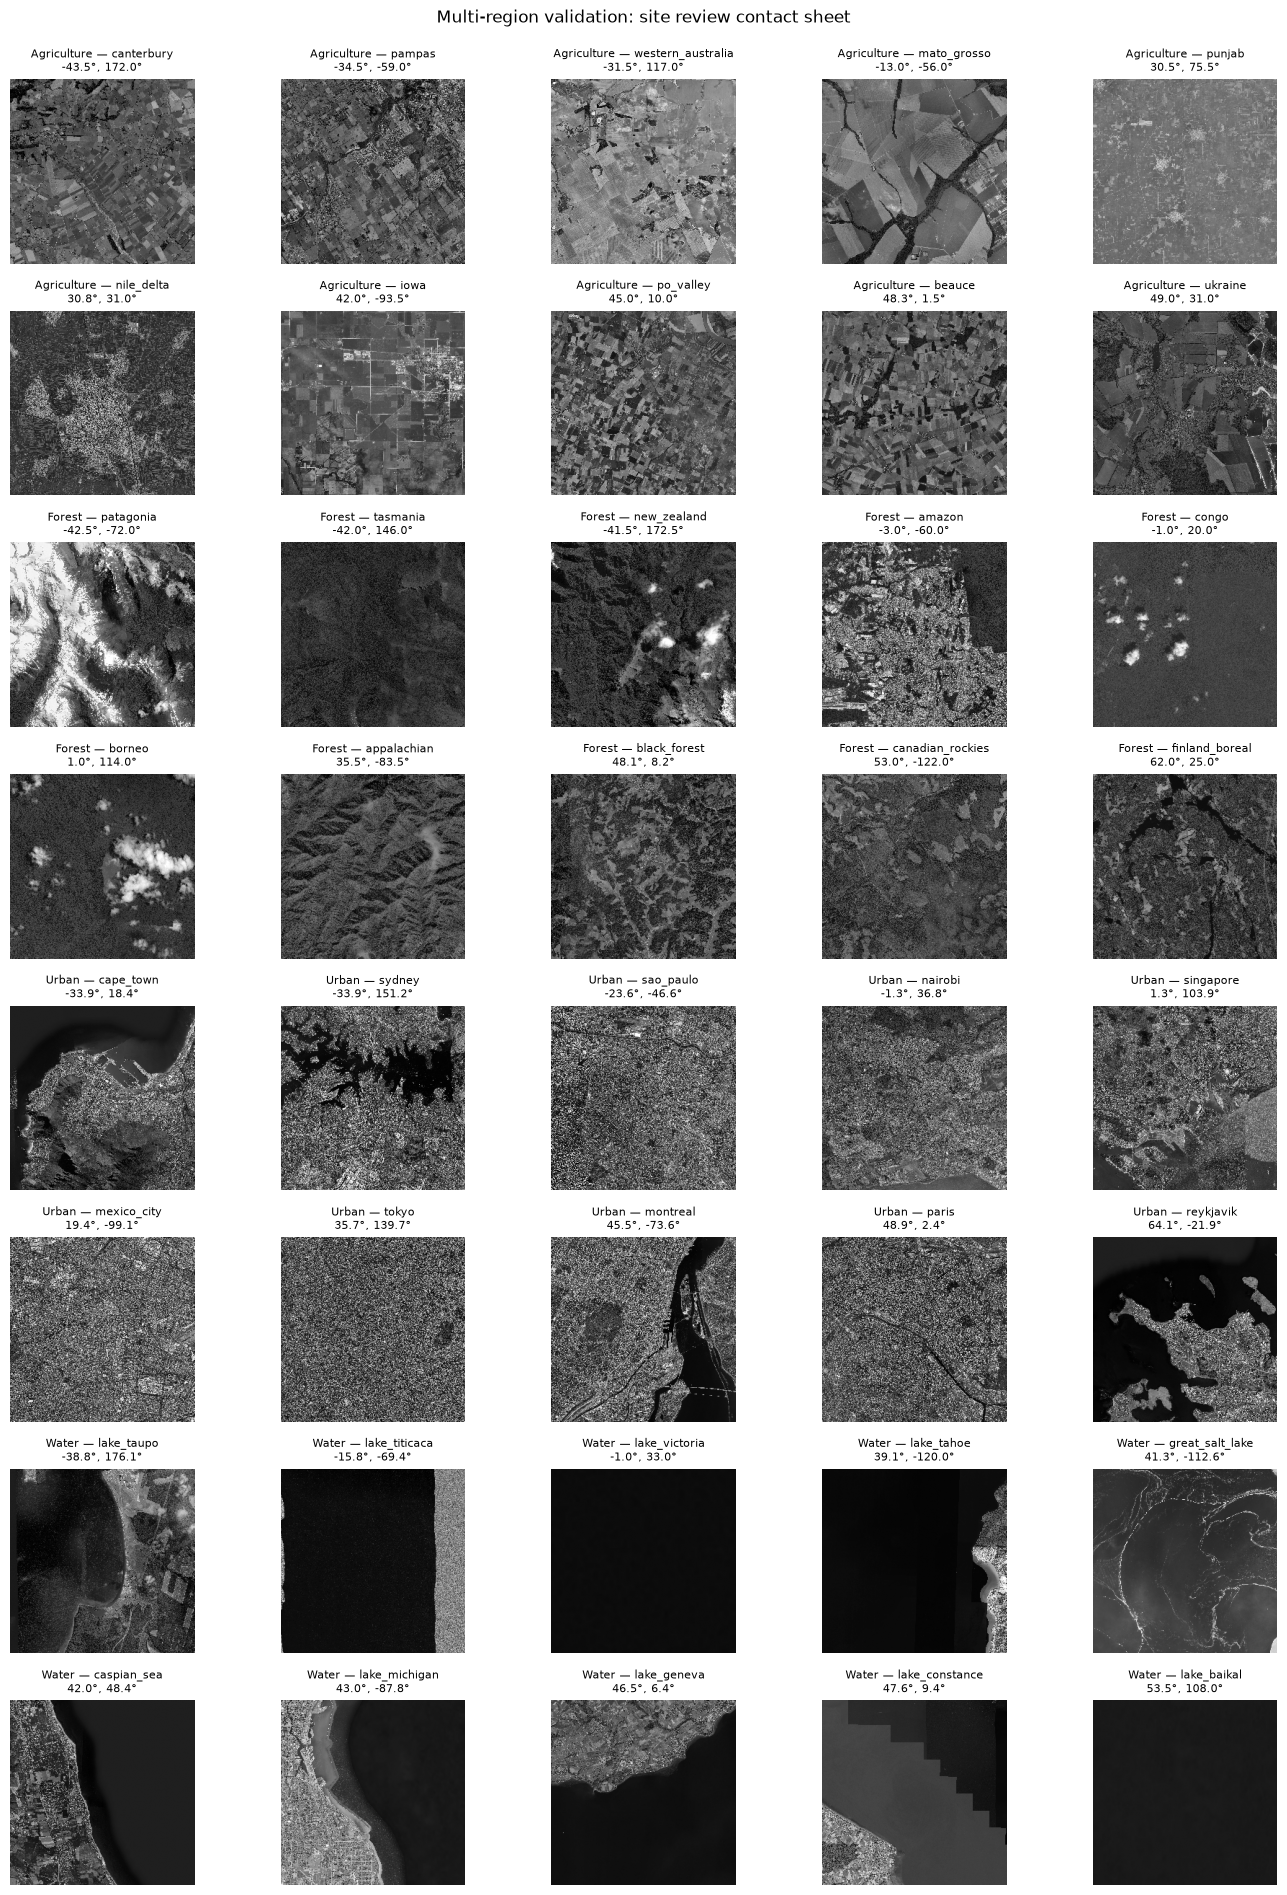

In [7]:
def region_preview(region_row, width_m=11000, pixels=256):
    epsg = utm_epsg_for_lonlat(region_row.anchor_lon, region_row.anchor_lat)
    crs_utm = pyproj.CRS.from_epsg(epsg)
    to_utm = pyproj.Transformer.from_crs(4326, crs_utm, always_xy=True)
    to_wgs = pyproj.Transformer.from_crs(crs_utm, 4326, always_xy=True)
    centre_x, centre_y = to_utm.transform(
        region_row.anchor_lon, region_row.anchor_lat
    )
    offset = np.linspace(-width_m / 2, width_m / 2, pixels)
    xx, yy = np.meshgrid(centre_x + offset, centre_y - offset)
    lon, lat = to_wgs.transform(xx, yy)
    return sample_esri_luminance(lon, lat)


def plot_region_contact_sheet(region_table):
    ordered = region_table.sort_values(["scene_class", "anchor_lat"])
    fig, axes = plt.subplots(8, 5, figsize=(14, 19))
    for axis, region in zip(axes.ravel(), ordered.itertuples(index=False)):
        preview = region_preview(region)
        axis.imshow(preview, cmap="gray", vmin=0, vmax=1)
        axis.set_title(
            f"{region.scene_class.capitalize()} — {region.region_id}\n"
            f"{region.anchor_lat:.1f}°, {region.anchor_lon:.1f}°",
            fontsize=8,
        )
        axis.axis("off")
    fig.suptitle("Multi-region validation: site review contact sheet", y=0.995)
    fig.tight_layout()
    fig.savefig(CONTACT_SHEET_PATH, dpi=180, bbox_inches="tight")
    return fig

FORCE_SITE_CONTACT_SHEET = True
CONTACT_SHEET_PATH = FIGURE_DIR / "multi_patch_site_contact_sheet.png"
if RUN_SITE_CONTACT_SHEET:
    if CONTACT_SHEET_PATH.exists() and not FORCE_SITE_CONTACT_SHEET:
        print(f"[Contact sheet cache] hit: {CONTACT_SHEET_PATH}")
        site_contact_sheet = Image.open(CONTACT_SHEET_PATH)
        display(site_contact_sheet)
    else:
        site_contact_sheet = plot_region_contact_sheet(regions[regions["include"]])
else:
    print("Contact sheet disabled. Enable it before approving the site manifest.")
ESRI_CACHE.clear_memory()
gc.collect()

## 3. Common-support metrics and reconstruction methods

The geometric baselines are evaluated as HEALPix cell averages: each detector
image is interpolated at the same nested child centres used to construct the
latent reference, then averaged within the parent cell. This avoids comparing a
point-sample baseline with a cell-average PSF-aware estimate.

In [8]:
def rmse(reference, estimate):
    reference = np.asarray(reference, dtype=np.float64)
    estimate = np.asarray(estimate, dtype=np.float64)
    finite = np.isfinite(reference) & np.isfinite(estimate)
    return float(np.sqrt(np.mean((estimate[finite] - reference[finite]) ** 2)))


def align_estimate(reference_ids, reference, estimated_ids, estimate):
    ref = pd.DataFrame({
        "cell_id": np.asarray(reference_ids, dtype=np.int64),
        "reference": np.asarray(reference, dtype=np.float64),
    })
    est = pd.DataFrame({
        "cell_id": np.asarray(estimated_ids, dtype=np.int64),
        "estimate": np.asarray(estimate, dtype=np.float64),
    })
    return ref.merge(est, on="cell_id", how="inner", validate="one_to_one")


def geometric_cell_average(products, method):
    interpolator = regular_interpolator(
        products["y"], products["x"], products["blurred_detector"], method=method
    )
    child_values = interpolator(
        np.column_stack([products["child_y"].ravel(), products["child_x"].ravel()])
    ).reshape(products["child_y"].shape)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        return np.nanmean(child_values, axis=1)


def synchronize_device():
    if DEVICE.startswith("cuda") and torch.cuda.is_available():
        torch.cuda.synchronize(torch.device(DEVICE))


def benchmark_environment():
    info = {
        "device": DEVICE,
        "cpu": platform.processor() or platform.machine(),
        "logical_cpu_count": os.cpu_count(),
        "python": platform.python_version(),
        "torch": torch.__version__,
        "healpix_resample": getattr(healpix_resample, "__version__", "unknown"),
        "platform": platform.platform(),
        "healpix_level": HEALPIX_LEVEL,
        "patch_size": PATCH_SIZE,
        "oversample": OVERSAMPLE,
        "lambda": LAMBDA,
        "max_iter": MAX_ITER,
    }
    if DEVICE.startswith("cuda") and torch.cuda.is_available():
        properties = torch.cuda.get_device_properties(torch.device(DEVICE))
        info.update({
            "accelerator": properties.name,
            "accelerator_memory_gib": properties.total_memory / 2**30,
            "cuda_version": torch.version.cuda,
        })
    else:
        info.update({
            "accelerator": "none",
            "accelerator_memory_gib": np.nan,
            "cuda_version": np.nan,
        })
    return info


def run_psf_aware(products, operator_fwhm_m):
    scale_m = fwhm_to_scale(operator_fwhm_m)
    npt_info = recommend_npt(
        scale_m, HEALPIX_LEVEL, target_mass=TARGET_KERNEL_MASS
    )
    npt = int(npt_info["npt"])
    synchronize_device()
    build_started = time.perf_counter()
    resampler = PSFResampler(
        lon_deg=products["lon"].ravel().astype(np.float64),
        lat_deg=products["lat"].ravel().astype(np.float64),
        level=HEALPIX_LEVEL,
        threshold=THRESHOLD,
        verbose=False,
        ellipsoid="sphere",
        sigma_m=scale_m,
        Npt=npt,
        device=DEVICE,
    )
    synchronize_device()
    operator_build_s = time.perf_counter() - build_started
    operator_rows, operator_cols = map(int, resampler.M.shape)
    operator_nnz = int(resampler.M._nnz())
    operator_density = operator_nnz / (operator_rows * operator_cols)
    solve_started = time.perf_counter()
    result = resampler.resample(
        products["blurred_detector"].ravel(), lam=LAMBDA, max_iter=MAX_ITER
    )
    synchronize_device()
    solve_s = time.perf_counter() - solve_started
    aligned = align_estimate(
        products["parent_ids"], products["hpx_latent"],
        result.cell_ids, result.cell_data,
    )
    output = {
        "cell_ids": np.asarray(result.cell_ids, dtype=np.int64),
        "cell_data": np.asarray(result.cell_data, dtype=np.float32),
        "rmse": rmse(aligned["reference"], aligned["estimate"]),
        "n_cells_compared": int(len(aligned)),
        "n_cells_estimated": int(len(result.cell_ids)),
        "npt": npt,
        "operator_rows": operator_rows,
        "operator_cols": operator_cols,
        "operator_nnz": operator_nnz,
        "operator_density": operator_density,
        "operator_build_s": operator_build_s,
        "solve_s": solve_s,
        "runtime_s": operator_build_s + solve_s,
    }
    del aligned, result, resampler
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return output

In [9]:
def radial_psd(image, pixel_size_m=DETECTOR_GSD_M):
    image = np.asarray(image, dtype=np.float64)
    finite = np.isfinite(image)
    fill = np.nanmean(image[finite]) if finite.any() else 0.0
    image = np.where(finite, image, fill)
    image = image - image.mean()
    wy = np.hanning(image.shape[0])
    wx = np.hanning(image.shape[1])
    windowed = image * np.sqrt(wy[:, None] * wx[None, :])
    power = np.abs(np.fft.fftshift(np.fft.fft2(windowed))) ** 2
    yy, xx = np.indices(image.shape)
    cy, cx = np.array(image.shape) // 2
    radius = np.sqrt((xx - cx) ** 2 + (yy - cy) ** 2).astype(np.int64)
    max_radius = min(image.shape) // 2
    sums = np.bincount(radius.ravel(), weights=power.ravel(), minlength=max_radius)
    counts = np.bincount(radius.ravel(), minlength=max_radius)
    psd = sums[:max_radius] / np.maximum(counts[:max_radius], 1)
    frequency = np.arange(max_radius) / (min(image.shape) * pixel_size_m)
    # Normalise per patch so brightness differences do not dominate bands.
    norm = np.sum(psd[1:])
    if norm > 0:
        psd = psd / norm
    return frequency[1:], psd[1:]


def hpx_estimate_to_detector_grid(cell_ids, values, products):
    cell_lon, cell_lat = hp.pix2ang(
        2 ** HEALPIX_LEVEL, np.asarray(cell_ids, dtype=np.int64),
        lonlat=True, nest=True,
    )
    target = np.column_stack([products["lon"].ravel(), products["lat"].ravel()])
    grid = griddata(
        np.column_stack([cell_lon, cell_lat]),
        np.asarray(values, dtype=np.float64),
        target,
        method="linear",
    )
    if np.any(~np.isfinite(grid)):
        nearest = griddata(
            np.column_stack([cell_lon, cell_lat]),
            np.asarray(values, dtype=np.float64),
            target,
            method="nearest",
        )
        grid = np.where(np.isfinite(grid), grid, nearest)
    return grid.reshape(products["latent_detector"].shape)

## 4. Patch execution, checkpointing, and provenance

Each patch writes its own metric CSV and spectrum NPZ. Its assembled Esri latent
texture is cached separately, so recomputing metrics does not retrieve or
resample the imagery again. A stopped run can be resumed without recomputing
completed patches. Failures are retained in a separate table and never silently
discarded.

In [10]:
METRIC_METHODS = [
    "blurred_observation",
    *OPERATOR_FWHM.keys(),
    "nearest",
    "bilinear",
    "bicubic",
]


def patch_cache_paths(patch_id):
    return (
        CACHE_DIR / f"{patch_id}__metrics.csv",
        CACHE_DIR / f"{patch_id}__spectra.npz",
    )


def _process_patch_impl(patch_row, force=False):
    patch_started = time.perf_counter()
    process = psutil.Process() if psutil is not None else None
    rss_start_mib = (
        process.memory_info().rss / 2**20 if process is not None else np.nan
    )
    metrics_path, spectra_path = patch_cache_paths(patch_row.patch_id)
    if metrics_path.exists() and spectra_path.exists() and not force:
        cache_started = time.perf_counter()
        metric_frame = pd.read_csv(metrics_path)
        spectra = dict(np.load(spectra_path))
        benchmark = {
            "patch_id": patch_row.patch_id,
            "scene_class": patch_row.scene_class,
            "region_id": patch_row.region_id,
            "patch_execution_status": "metric_cache_hit",
            "metric_cache_read_s": time.perf_counter() - cache_started,
            "esri_patch_cache_status": "not_accessed",
            "esri_patch_load_s": np.nan,
            "synthetic_build_s": np.nan,
            "spectral_analysis_s": np.nan,
            "checkpoint_write_s": 0.0,
            "patch_wall_s": time.perf_counter() - patch_started,
            "peak_gpu_memory_mib": np.nan,
            "rss_start_mib": rss_start_mib,
            "rss_end_mib": (
                process.memory_info().rss / 2**20 if process is not None else np.nan
            ),
        }
        return metric_frame, spectra, benchmark

    if DEVICE.startswith("cuda") and torch.cuda.is_available():
        synchronize_device()
        torch.cuda.reset_peak_memory_stats(torch.device(DEVICE))
    products = build_synthetic_patch(patch_row)
    degradation = rmse(products["hpx_latent"], products["hpx_blurred"])
    if not np.isfinite(degradation) or degradation <= 0:
        raise ValueError(f"Invalid PSF degradation for {patch_row.patch_id}: {degradation}")

    base = {
        key: getattr(patch_row, key)
        for key in [
            "patch_id", "scene_class", "region_id", "location",
            "anchor_lat", "anchor_lon", "patch_lat", "patch_lon",
            "abs_latitude_band", "utm_epsg", "east_offset_m", "north_offset_m",
        ]
    }
    base.update({
        "true_fwhm_m": TRUE_FWHM_M,
        "lambda": LAMBDA,
        "max_iter": MAX_ITER,
        "healpix_level": HEALPIX_LEVEL,
        "device": DEVICE,
        "rmse_psf_degradation": degradation,
    })

    rows = [{
        **base,
        "method": "blurred_observation",
        "operator_fwhm_m": TRUE_FWHM_M,
        "rmse_vs_latent": degradation,
        "recovery_fraction": 0.0,
        "n_cells_compared": len(products["parent_ids"]),
        "n_cells_estimated": len(products["parent_ids"]),
        "npt": np.nan,
        "operator_rows": np.nan,
        "operator_cols": np.nan,
        "operator_nnz": np.nan,
        "operator_density": np.nan,
        "operator_build_s": 0.0,
        "solve_s": 0.0,
        "projection_s": 0.0,
        "runtime_s": 0.0,
    }]

    estimates_for_spectra = {}
    for method_name, operator_fwhm in OPERATOR_FWHM.items():
        result = run_psf_aware(products, operator_fwhm)
        method_rmse = result["rmse"]
        rows.append({
            **base,
            "method": method_name,
            "operator_fwhm_m": operator_fwhm,
            "rmse_vs_latent": method_rmse,
            "recovery_fraction": 1.0 - method_rmse / degradation,
            "n_cells_compared": result["n_cells_compared"],
            "n_cells_estimated": result["n_cells_estimated"],
            "npt": result["npt"],
            "operator_rows": result["operator_rows"],
            "operator_cols": result["operator_cols"],
            "operator_nnz": result["operator_nnz"],
            "operator_density": result["operator_density"],
            "operator_build_s": result["operator_build_s"],
            "solve_s": result["solve_s"],
            "projection_s": np.nan,
            "runtime_s": result["runtime_s"],
        })
        projection_started = time.perf_counter()
        estimates_for_spectra[method_name] = hpx_estimate_to_detector_grid(
            result["cell_ids"], result["cell_data"], products
        )
        rows[-1]["projection_s"] = time.perf_counter() - projection_started
        del result

    for display_name, scipy_method in [
        ("nearest", "nearest"), ("bilinear", "linear"), ("bicubic", "cubic")
    ]:
        started = time.perf_counter()
        estimate = geometric_cell_average(products, scipy_method)
        elapsed = time.perf_counter() - started
        method_rmse = rmse(products["hpx_latent"], estimate)
        rows.append({
            **base,
            "method": display_name,
            "operator_fwhm_m": np.nan,
            "rmse_vs_latent": method_rmse,
            "recovery_fraction": 1.0 - method_rmse / degradation,
            "n_cells_compared": int(np.isfinite(estimate).sum()),
            "n_cells_estimated": len(estimate),
            "npt": np.nan,
            "operator_rows": np.nan,
            "operator_cols": np.nan,
            "operator_nnz": np.nan,
            "operator_density": np.nan,
            "operator_build_s": 0.0,
            "solve_s": elapsed,
            "projection_s": 0.0,
            "runtime_s": elapsed,
        })

    spectral_started = time.perf_counter()
    frequency, latent_psd = radial_psd(products["latent_detector"])
    _, blurred_psd = radial_psd(products["blurred_detector"])
    spectra = {
        "frequency_m_inv": frequency,
        "psd_latent": latent_psd,
        "psd_blurred": blurred_psd,
        "asr_blurred": np.abs(blurred_psd - latent_psd),
    }
    for method_name, image in estimates_for_spectra.items():
        _, method_psd = radial_psd(image)
        spectra[f"psd_{method_name}"] = method_psd
        spectra[f"asr_{method_name}"] = np.abs(method_psd - latent_psd)
    spectral_analysis_s = time.perf_counter() - spectral_started

    metric_frame = pd.DataFrame(rows)
    metric_frame["method_total_s"] = (
        metric_frame["runtime_s"] + metric_frame["projection_s"].fillna(0.0)
    )
    checkpoint_started = time.perf_counter()
    metric_frame.to_csv(metrics_path, index=False)
    np.savez_compressed(spectra_path, **spectra)
    checkpoint_write_s = time.perf_counter() - checkpoint_started
    if DEVICE.startswith("cuda") and torch.cuda.is_available():
        synchronize_device()
        peak_gpu_memory_mib = (
            torch.cuda.max_memory_allocated(torch.device(DEVICE)) / 2**20
        )
    else:
        peak_gpu_memory_mib = np.nan
    psf_metric_rows = metric_frame[metric_frame["method"].str.startswith("psf_aware")]
    benchmark = {
        "patch_id": patch_row.patch_id,
        "scene_class": patch_row.scene_class,
        "region_id": patch_row.region_id,
        "patch_execution_status": "computed",
        "metric_cache_read_s": 0.0,
        **products["benchmark"],
        "spectral_analysis_s": spectral_analysis_s,
        "checkpoint_write_s": checkpoint_write_s,
        "patch_wall_s": time.perf_counter() - patch_started,
        "peak_gpu_memory_mib": peak_gpu_memory_mib,
        "operator_nnz_total": psf_metric_rows["operator_nnz"].sum(),
        "healpix_cells_max": psf_metric_rows["n_cells_estimated"].max(),
        "rss_start_mib": rss_start_mib,
        "rss_end_mib": (
            process.memory_info().rss / 2**20 if process is not None else np.nan
        ),
    }
    return metric_frame, spectra, benchmark


def release_patch_memory():
    """Drop per-patch CPU/GPU caches while preserving disk caches."""
    ESRI_CACHE.clear_memory()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        if hasattr(torch.cuda, "ipc_collect"):
            torch.cuda.ipc_collect()
    gc.collect()


def process_patch(patch_row, force=False):
    process = psutil.Process() if psutil is not None else None
    peak_rss_mib = [
        process.memory_info().rss / 2**20 if process is not None else np.nan
    ]
    stop_sampling = threading.Event()

    def sample_rss():
        while not stop_sampling.wait(0.05):
            peak_rss_mib[0] = max(
                peak_rss_mib[0], process.memory_info().rss / 2**20
            )

    sampler = None
    if process is not None:
        sampler = threading.Thread(target=sample_rss, daemon=True)
        sampler.start()
    try:
        result = _process_patch_impl(patch_row, force=force)
    finally:
        cleanup_started = time.perf_counter()
        release_patch_memory()
        cleanup_s = time.perf_counter() - cleanup_started
        stop_sampling.set()
        if sampler is not None:
            sampler.join()
            peak_rss_mib[0] = max(
                peak_rss_mib[0], process.memory_info().rss / 2**20
            )
    result[2]["cleanup_s"] = cleanup_s
    result[2]["patch_wall_s"] += cleanup_s
    result[2]["peak_rss_mib"] = peak_rss_mib[0]
    if psutil is not None:
        result[2]["rss_after_cleanup_mib"] = psutil.Process().memory_info().rss / 2**20
    else:
        result[2]["rss_after_cleanup_mib"] = np.nan
    return result


def run_experiment(manifest, force=False, limit=None):
    if not SITES_APPROVED:
        raise RuntimeError("Set SITES_APPROVED = True after reviewing the site manifest.")
    selected = manifest if limit is None else manifest.head(int(limit))
    run_started = time.perf_counter()
    metric_frames = []
    benchmark_rows = []
    failures = []
    computed_count = 0
    failure_columns = [
        "patch_id", "scene_class", "region_id", "error_type", "error"
    ]
    for number, patch_row in enumerate(selected.itertuples(index=False), start=1):
        print(f"[{number:03d}/{len(selected):03d}] {patch_row.patch_id}", flush=True)
        try:
            frame, _, benchmark = process_patch(patch_row, force=force)
            is_computed = benchmark["patch_execution_status"] == "computed"
            if is_computed:
                computed_count += 1
            benchmark_included = (
                is_computed and computed_count > BENCHMARK_WARMUP_PATCHES
            )
            benchmark.update({
                "run_sequence": number,
                "benchmark_included": benchmark_included,
            })
            frame = frame.copy()
            frame["patch_execution_status"] = benchmark["patch_execution_status"]
            frame["run_sequence"] = number
            frame["benchmark_included"] = benchmark_included
            metric_frames.append(frame)
            benchmark_rows.append(benchmark)
        except Exception as exc:
            failures.append({
                "patch_id": patch_row.patch_id,
                "scene_class": patch_row.scene_class,
                "region_id": patch_row.region_id,
                "error_type": type(exc).__name__,
                "error": str(exc),
            })
        if metric_frames:
            pd.concat(metric_frames, ignore_index=True).to_csv(
                TABLE_DIR / "multi_patch_latitude_metrics.csv", index=False
            )
        pd.DataFrame(benchmark_rows).to_csv(
            TABLE_DIR / "multi_patch_runtime_by_patch.csv", index=False
        )
        pd.DataFrame(failures, columns=failure_columns).to_csv(
            TABLE_DIR / "multi_patch_latitude_failures.csv", index=False
        )

    tile_audit = pd.DataFrame(ESRI_CACHE.audit_rows).drop_duplicates()
    tile_audit.to_csv(TABLE_DIR / "multi_patch_tile_provenance.csv", index=False)
    metrics = (
        pd.concat(metric_frames, ignore_index=True)
        if metric_frames else pd.DataFrame()
    )
    benchmark_frame = pd.DataFrame(benchmark_rows)
    included = (
        benchmark_frame[benchmark_frame["benchmark_included"].fillna(False)]
        if not benchmark_frame.empty else pd.DataFrame()
    )
    status = (
        benchmark_frame["patch_execution_status"]
        if not benchmark_frame.empty else pd.Series(dtype=object)
    )
    benchmark_wall_s = (
        included["patch_wall_s"].sum() if not included.empty else np.nan
    )
    run_summary = {
        **benchmark_environment(),
        "patches_selected": len(selected),
        "patches_computed": int((status == "computed").sum()),
        "metric_cache_hits": int((status == "metric_cache_hit").sum()),
        "warmup_patches_excluded": min(computed_count, BENCHMARK_WARMUP_PATCHES),
        "benchmark_patches": len(included),
        "failures": len(failures),
        "run_wall_s": time.perf_counter() - run_started,
        "benchmark_patch_wall_s": benchmark_wall_s,
        "benchmark_patches_per_hour": (
            3600.0 * len(included) / benchmark_wall_s
            if np.isfinite(benchmark_wall_s) and benchmark_wall_s > 0 else np.nan
        ),
    }
    pd.DataFrame([run_summary]).to_csv(
        TABLE_DIR / "multi_patch_run_summary.csv", index=False
    )
    return (
        metrics, pd.DataFrame(failures, columns=failure_columns), benchmark_frame
    )

In [11]:
# Optional one-patch smoke test. Enable only after inspecting the manifest.
if RUN_SMOKE_TEST:
    smoke_metrics, smoke_failures, smoke_benchmark = run_experiment(
        patch_manifest.head(1), force=True, limit=1
    )
    display(smoke_metrics)
    display(smoke_benchmark)
    display(smoke_failures)
else:
    print("Smoke test disabled. Set SITES_APPROVED=True and RUN_SMOKE_TEST=True to run it.")

[001/001] urban__singapore__r0c0
[Esri patch cache] hit: urban__singapore__r0c0


/home/jovyan/healpix-resample/healpix_resample/psf.py:600: UserWarning: Sparse CSR tensor support is in beta state. If you miss a functionality in the sparse tensor support, please submit a feature request to https://github.com/pytorch/pytorch/issues. (Triggered internally at /home/conda/feedstock_root/build_artifacts/libtorch_1780240370028/work/aten/src/ATen/SparseCsrTensorImpl.cpp:49.)
  self.MT = MT_coo.to_sparse_csr()


,patch_id,scene_class,region_id,location,anchor_lat,anchor_lon,patch_lat,patch_lon,abs_latitude_band,utm_epsg,...,operator_nnz,operator_density,operator_build_s,solve_s,projection_s,runtime_s,method_total_s,patch_execution_status,run_sequence,benchmark_included
0,urban__singapore__r0c0,urban,singapore,Singapore,1.2903,103.8519,1.254102,103.815968,00-15,32648,...,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,computed,1,False
1,urban__singapore__r0c0,urban,singapore,Singapore,1.2903,103.8519,1.254102,103.815968,00-15,32648,...,1441792.0,0.000128,0.832000,0.117045,2.312554,0.949045,3.261599,computed,1,False
2,urban__singapore__r0c0,urban,singapore,Singapore,1.2903,103.8519,1.254102,103.815968,00-15,32648,...,3145728.0,0.000276,0.931268,0.277459,2.242193,1.208728,3.450921,computed,1,False
3,urban__singapore__r0c0,urban,singapore,Singapore,1.2903,103.8519,1.254102,103.815968,00-15,32648,...,589824.0,0.000053,0.193746,0.024847,2.207446,0.218593,2.426040,computed,1,False
4,urban__singapore__r0c0,urban,singapore,Singapore,1.2903,103.8519,1.254102,103.815968,00-15,32648,...,NaN,NaN,0.000000,0.133248,0.000000,0.133248,0.133248,computed,1,False
5,urban__singapore__r0c0,urban,singapore,Singapore,1.2903,103.8519,1.254102,103.815968,00-15,32648,...,NaN,NaN,0.000000,0.108817,0.000000,0.108817,0.108817,computed,1,False
6,urban__singapore__r0c0,urban,singapore,Singapore,1.2903,103.8519,1.254102,103.815968,00-15,32648,...,NaN,NaN,0.000000,0.797857,0.000000,0.797857,0.797857,computed,1,False


,patch_id,scene_class,region_id,patch_execution_status,metric_cache_read_s,esri_patch_cache_status,esri_patch_load_s,synthetic_build_s,spectral_analysis_s,checkpoint_write_s,...,peak_gpu_memory_mib,operator_nnz_total,healpix_cells_max,rss_start_mib,rss_end_mib,cleanup_s,peak_rss_mib,rss_after_cleanup_mib,run_sequence,benchmark_included
0,urban__singapore__r0c0,urban,singapore,computed,0.0,zarr_hit,0.178668,1.608856,0.008922,0.021545,...,1021.457031,5177344.0,174025,18537.261719,18748.292969,0.156259,18748.292969,18748.289062,1,False


,patch_id,scene_class,region_id,error_type,error


In [12]:
# Full production run. Zarr imagery is always reused; metric caches are optional.
if RUN_FULL_EXPERIMENT:
    metrics, failures, benchmark = run_experiment(
        patch_manifest, force=FORCE_RECOMPUTE_METRICS_FOR_BENCHMARK
    )
    print(f"Rows written: {len(metrics)}")
    print(f"Failed patches: {len(failures)}")
else:
    metrics_path = TABLE_DIR / "multi_patch_latitude_metrics.csv"
    metrics = pd.read_csv(metrics_path) if metrics_path.exists() else pd.DataFrame()
    failures_path = TABLE_DIR / "multi_patch_latitude_failures.csv"
    failures = pd.read_csv(failures_path) if failures_path.exists() else pd.DataFrame()
    benchmark_path = TABLE_DIR / "multi_patch_runtime_by_patch.csv"
    benchmark = (
        pd.read_csv(benchmark_path) if benchmark_path.exists() else pd.DataFrame()
    )
    print("Full run disabled; loaded existing outputs when available.")

[001/360] urban__singapore__r0c0
[Esri patch cache] hit: urban__singapore__r0c0
[002/360] urban__singapore__r0c1
[Esri patch cache] hit: urban__singapore__r0c1
[003/360] urban__singapore__r0c2
[Esri patch cache] hit: urban__singapore__r0c2
[004/360] urban__singapore__r1c0
[Esri patch cache] hit: urban__singapore__r1c0
[005/360] urban__singapore__r1c1
[Esri patch cache] hit: urban__singapore__r1c1
[006/360] urban__singapore__r1c2
[Esri patch cache] hit: urban__singapore__r1c2
[007/360] urban__singapore__r2c0
[Esri patch cache] hit: urban__singapore__r2c0
[008/360] urban__singapore__r2c1
[Esri patch cache] hit: urban__singapore__r2c1
[009/360] urban__singapore__r2c2
[Esri patch cache] hit: urban__singapore__r2c2
[010/360] urban__nairobi__r0c0
[Esri patch cache] hit: urban__nairobi__r0c0
[011/360] urban__nairobi__r0c1
[Esri patch cache] hit: urban__nairobi__r0c1
[012/360] urban__nairobi__r0c2
[Esri patch cache] hit: urban__nairobi__r0c2
[013/360] urban__nairobi__r1c0
[Esri patch cache] hi

/tmp/ipykernel_1118/165291766.py:125: UserWarning: Ignoring invalid Esri patch cache /home/jovyan/healpix-resample/notebooks/data/multi_patch_latitude/esri_patch_cache/water__lake_geneva__r0c0__z17_n256_os4_gsd10.zarr: cached patch metadata does not match the manifest
  warnings.warn(f"Ignoring invalid Esri patch cache {cache_path}: {exc}")


[Esri patch cache] wrote: water__lake_geneva__r0c0
[119/360] water__lake_geneva__r0c1


/tmp/ipykernel_1118/165291766.py:125: UserWarning: Ignoring invalid Esri patch cache /home/jovyan/healpix-resample/notebooks/data/multi_patch_latitude/esri_patch_cache/water__lake_geneva__r0c1__z17_n256_os4_gsd10.zarr: cached patch metadata does not match the manifest
  warnings.warn(f"Ignoring invalid Esri patch cache {cache_path}: {exc}")


[Esri patch cache] wrote: water__lake_geneva__r0c1
[120/360] water__lake_geneva__r0c2


...

[Esri patch cache] wrote: water__great_salt_lake__r2c0
[152/360] water__great_salt_lake__r2c1


/tmp/ipykernel_1118/165291766.py:125: UserWarning: Ignoring invalid Esri patch cache /home/jovyan/healpix-resample/notebooks/data/multi_patch_latitude/esri_patch_cache/water__great_salt_lake__r2c1__z17_n256_os4_gsd10.zarr: cached patch metadata does not match the manifest
  warnings.warn(f"Ignoring invalid Esri patch cache {cache_path}: {exc}")


[Esri patch cache] wrote: water__great_salt_lake__r2c1
[153/360] water__great_salt_lake__r2c2


/tmp/ipykernel_1118/165291766.py:125: UserWarning: Ignoring invalid Esri patch cache /home/jovyan/healpix-resample/notebooks/data/multi_patch_latitude/esri_patch_cache/water__great_salt_lake__r2c2__z17_n256_os4_gsd10.zarr: cached patch metadata does not match the manifest
  warnings.warn(f"Ignoring invalid Esri patch cache {cache_path}: {exc}")


[Esri patch cache] wrote: water__great_salt_lake__r2c2
[154/360] water__caspian_sea__r0c0
[Esri patch cache] hit: water__caspian_sea__r0c0
[155/360] water__caspian_sea__r0c1
[Esri patch cache] hit: water__caspian_sea__r0c1
[156/360] water__caspian_sea__r0c2
[Esri patch cache] hit: water__caspian_sea__r0c2
[157/360] water__caspian_sea__r1c0
[Esri patch cache] hit: water__caspian_sea__r1c0
[158/360] water__caspian_sea__r1c1
[Esri patch cache] hit: water__caspian_sea__r1c1
[159/360] water__caspian_sea__r1c2
[Esri patch cache] hit: water__caspian_sea__r1c2
[160/360] water__caspian_sea__r2c0
[Esri patch cache] hit: water__caspian_sea__r2c0
[161/360] water__caspian_sea__r2c1
[Esri patch cache] hit: water__caspian_sea__r2c1
[162/360] water__caspian_sea__r2c2
[Esri patch cache] hit: water__caspian_sea__r2c2
[163/360] water__lake_constance__r0c0
[Esri patch cache] hit: water__lake_constance__r0c0
[164/360] water__lake_constance__r0c1
[Esri patch cache] hit: water__lake_constance__r0c1
[165/360]

## 5. Region-aware summaries

Patch-level rows are useful for diagnostics, but uncertainty is calculated from
region means. This protects the confidence intervals against pseudo-replication
caused by the nine spatially related patches surrounding each anchor.

In [13]:
def cluster_bootstrap_mean(region_values, n_boot=5000, seed=RANDOM_SEED):
    values = np.asarray(region_values, dtype=np.float64)
    values = values[np.isfinite(values)]
    if len(values) < 2:
        return np.nan, np.nan
    rng = np.random.default_rng(seed)
    indices = rng.integers(0, len(values), size=(n_boot, len(values)))
    boot = values[indices].mean(axis=1)
    return tuple(np.quantile(boot, [0.025, 0.975]))


def make_summary_tables(metric_frame):
    if metric_frame.empty:
        return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

    region_means = (
        metric_frame.groupby(
            ["scene_class", "region_id", "abs_latitude_band", "method"],
            observed=True,
        )
        .agg(
            rmse=("rmse_vs_latent", "mean"),
            recovery=("recovery_fraction", "mean"),
            patches=("patch_id", "nunique"),
            latitude=("patch_lat", "mean"),
        )
        .reset_index()
    )

    summary_rows = []
    for (scene_class, method), group in region_means.groupby(
        ["scene_class", "method"], observed=True
    ):
        rmse_low, rmse_high = cluster_bootstrap_mean(group["rmse"])
        rec_low, rec_high = cluster_bootstrap_mean(group["recovery"])
        summary_rows.append({
            "scene_class": scene_class,
            "method": method,
            "n_regions": group["region_id"].nunique(),
            "n_patches": int(group["patches"].sum()),
            "rmse_region_mean": group["rmse"].mean(),
            "rmse_region_sd": group["rmse"].std(ddof=1),
            "rmse_ci95_low": rmse_low,
            "rmse_ci95_high": rmse_high,
            "recovery_region_mean": group["recovery"].mean(),
            "recovery_ci95_low": rec_low,
            "recovery_ci95_high": rec_high,
        })
    summary = pd.DataFrame(summary_rows)

    latitude_summary = (
        region_means.groupby(
            ["scene_class", "abs_latitude_band", "method"], observed=True
        )
        .agg(
            n_regions=("region_id", "nunique"),
            n_patches=("patches", "sum"),
            rmse_mean=("rmse", "mean"),
            rmse_sd=("rmse", "std"),
            recovery_mean=("recovery", "mean"),
            recovery_sd=("recovery", "std"),
        )
        .reset_index()
    )

    patch_pivot = metric_frame.pivot_table(
        index=["scene_class", "region_id", "patch_id"],
        columns="method", values="rmse_vs_latent", aggfunc="first"
    ).reset_index()
    comparison_rows = []
    reference_method = "psf_aware_matched"
    for competitor in [
        "psf_aware_plus50", "psf_aware_minus50",
        "nearest", "bilinear", "bicubic",
    ]:
        if competitor not in patch_pivot or reference_method not in patch_pivot:
            continue
        paired = patch_pivot.dropna(subset=[reference_method, competitor]).copy()
        paired["delta_rmse"] = paired[competitor] - paired[reference_method]
        region_delta = (
            paired.groupby(["scene_class", "region_id"])["delta_rmse"]
            .mean().reset_index()
        )
        for scene_class, group in region_delta.groupby("scene_class"):
            low, high = cluster_bootstrap_mean(group["delta_rmse"])
            patch_subset = paired[paired["scene_class"] == scene_class]
            comparison_rows.append({
                "scene_class": scene_class,
                "reference_method": reference_method,
                "competitor": competitor,
                "n_regions": group["region_id"].nunique(),
                "n_patches": len(patch_subset),
                "mean_paired_delta_rmse": group["delta_rmse"].mean(),
                "delta_ci95_low": low,
                "delta_ci95_high": high,
                "matched_win_fraction": float(
                    (patch_subset[reference_method] < patch_subset[competitor]).mean()
                ),
            })
    comparisons = pd.DataFrame(comparison_rows)
    return summary, latitude_summary, comparisons


def describe_runtime(series):
    values = pd.to_numeric(series, errors="coerce").dropna()
    return {
        "mean_s": values.mean(),
        "sd_s": values.std(ddof=1),
        "median_s": values.median(),
        "q25_s": values.quantile(0.25),
        "q75_s": values.quantile(0.75),
    }


def make_runtime_tables(metric_frame, benchmark_frame):
    required_metric = {"benchmark_included", "method", "method_total_s"}
    if metric_frame.empty or not required_metric.issubset(metric_frame.columns):
        return pd.DataFrame(), pd.DataFrame()
    timed_metrics = metric_frame[
        metric_frame["benchmark_included"].fillna(False)
        & metric_frame["method"].ne("blurred_observation")
    ]
    method_rows = []
    for method, group in timed_metrics.groupby("method", observed=True):
        row = {"method": method, "n_patches": group["patch_id"].nunique()}
        for column in [
            "operator_build_s", "solve_s", "projection_s", "method_total_s"
        ]:
            for statistic, value in describe_runtime(group[column]).items():
                row[f"{column}_{statistic}"] = value
        for column in ["npt", "operator_nnz", "operator_density", "n_cells_estimated"]:
            values = pd.to_numeric(group[column], errors="coerce").dropna()
            row[f"{column}_median"] = values.median()
            row[f"{column}_q25"] = values.quantile(0.25)
            row[f"{column}_q75"] = values.quantile(0.75)
        method_rows.append(row)

    stage_rows = []
    if not benchmark_frame.empty and "benchmark_included" in benchmark_frame:
        timed_patches = benchmark_frame[
            benchmark_frame["benchmark_included"].fillna(False)
        ]
        for column in [
            "esri_patch_load_s", "synthetic_build_s", "spectral_analysis_s",
            "checkpoint_write_s", "cleanup_s", "patch_wall_s",
            "peak_gpu_memory_mib",
            "peak_rss_mib", "rss_start_mib", "rss_end_mib",
            "rss_after_cleanup_mib",
        ]:
            if column not in timed_patches:
                continue
            stage_rows.append({
                "stage": column,
                "n_patches": timed_patches["patch_id"].nunique(),
                **describe_runtime(timed_patches[column]),
            })
    return pd.DataFrame(method_rows), pd.DataFrame(stage_rows)


def make_patch_scaling_table(benchmark_frame):
    if benchmark_frame.empty or "benchmark_included" not in benchmark_frame:
        return pd.DataFrame()
    timed = (
        benchmark_frame[benchmark_frame["benchmark_included"].fillna(False)]
        .sort_values("run_sequence")
        .reset_index(drop=True)
    )
    if timed.empty:
        return pd.DataFrame()
    checkpoints = sorted({
        count for count in [1, 2, 5, 10, 20, 50, 100, 200, len(timed)]
        if count <= len(timed)
    })
    rows = []
    for count in checkpoints:
        subset = timed.head(count)
        wall_s = subset["patch_wall_s"].sum()
        rows.append({
            "n_patches": count,
            "cumulative_patch_wall_s": wall_s,
            "patches_per_hour": 3600.0 * count / wall_s,
            "cumulative_operator_nnz": subset["operator_nnz_total"].sum(),
            "median_healpix_cells": subset["healpix_cells_max"].median(),
            "peak_rss_mib": subset["peak_rss_mib"].max(),
            "peak_gpu_memory_mib": subset["peak_gpu_memory_mib"].max(),
        })
    return pd.DataFrame(rows)


summary, latitude_summary, comparisons = make_summary_tables(metrics)
runtime_by_method, runtime_stages = make_runtime_tables(metrics, benchmark)
runtime_scaling = make_patch_scaling_table(benchmark)
if not metrics.empty:
    summary.to_csv(TABLE_DIR / "multi_patch_latitude_summary.csv", index=False)
    latitude_summary.to_csv(
        TABLE_DIR / "multi_patch_latitude_by_band.csv", index=False
    )
    comparisons.to_csv(
        TABLE_DIR / "multi_patch_method_comparisons.csv", index=False
    )
    runtime_by_method.to_csv(
        TABLE_DIR / "multi_patch_runtime_by_method.csv", index=False
    )
    runtime_stages.to_csv(
        TABLE_DIR / "multi_patch_runtime_stages.csv", index=False
    )
    runtime_scaling.to_csv(
        TABLE_DIR / "multi_patch_runtime_scaling.csv", index=False
    )
    display(summary)
    display(comparisons)
    display(runtime_by_method)
    display(runtime_stages)
    display(runtime_scaling)

,scene_class,method,n_regions,n_patches,rmse_region_mean,rmse_region_sd,rmse_ci95_low,rmse_ci95_high,recovery_region_mean,recovery_ci95_low,recovery_ci95_high
0,agriculture,bicubic,10,90,0.031472,0.012443,0.024724,0.039400,-0.140498,-0.149002,-0.133744
1,agriculture,bilinear,10,90,0.034655,0.013506,0.027262,0.043206,-0.258422,-0.273774,-0.245121
2,agriculture,blurred_observation,10,90,0.027630,0.010998,0.021692,0.034634,0.000000,0.000000,0.000000
3,agriculture,nearest,10,90,0.033322,0.013009,0.026232,0.041567,-0.209791,-0.221714,-0.199489
4,agriculture,psf_aware_matched,10,90,0.022300,0.009200,0.017389,0.028226,0.195580,0.180094,0.210565
5,agriculture,psf_aware_minus50,10,90,0.031854,0.012481,0.025071,0.039761,-0.156223,-0.164368,-0.148996
6,agriculture,psf_aware_plus50,10,90,0.043134,0.016654,0.033915,0.053547,-0.568157,-0.614272,-0.526750
7,forest,bicubic,10,90,0.034568,0.012461,0.028083,0.042586,-0.120364,-0.127477,-0.113913
8,forest,bilinear,10,90,0.037377,0.013824,0.030155,0.046256,-0.208678,-0.227712,-0.191990
9,forest,blurred_observation,10,90,0.030790,0.010829,0.025165,0.037812,0.000000,0.000000,0.000000


,scene_class,reference_method,competitor,n_regions,n_patches,mean_paired_delta_rmse,delta_ci95_low,delta_ci95_high,matched_win_fraction
0,agriculture,psf_aware_matched,psf_aware_plus50,10,90,0.020834,0.016369,0.025611,1.0
1,forest,psf_aware_matched,psf_aware_plus50,10,90,0.020193,0.015457,0.025873,1.0
2,urban,psf_aware_matched,psf_aware_plus50,10,90,0.048337,0.039792,0.056391,1.0
3,water,psf_aware_matched,psf_aware_plus50,10,88,0.008748,0.004842,0.012740,1.0
4,agriculture,psf_aware_matched,psf_aware_minus50,10,90,0.009554,0.007563,0.011717,1.0
5,forest,psf_aware_matched,psf_aware_minus50,10,90,0.008803,0.006560,0.011509,1.0
6,urban,psf_aware_matched,psf_aware_minus50,10,90,0.021625,0.018157,0.024856,1.0
7,water,psf_aware_matched,psf_aware_minus50,10,88,0.003949,0.002195,0.005718,1.0
8,agriculture,psf_aware_matched,nearest,10,90,0.011022,0.008722,0.013519,1.0
9,forest,psf_aware_matched,nearest,10,90,0.010200,0.007623,0.013305,1.0


,method,n_patches,operator_build_s_mean_s,operator_build_s_sd_s,operator_build_s_median_s,operator_build_s_q25_s,operator_build_s_q75_s,solve_s_mean_s,solve_s_sd_s,solve_s_median_s,...,npt_q75,operator_nnz_median,operator_nnz_q25,operator_nnz_q75,operator_density_median,operator_density_q25,operator_density_q75,n_cells_estimated_median,n_cells_estimated_q25,n_cells_estimated_q75
0,bicubic,357,0.000000,0.000000,0.000000,0.000000,0.000000,0.759347,0.032101,0.754173,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,169936.0,169703.0,170414.0
1,bilinear,357,0.000000,0.000000,0.000000,0.000000,0.000000,0.109363,0.025864,0.106099,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,169936.0,169703.0,170414.0
2,nearest,357,0.000000,0.000000,0.000000,0.000000,0.000000,0.127082,0.035695,0.119063,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,169936.0,169703.0,170414.0
3,psf_aware_matched,357,0.285441,0.021448,0.282175,0.279160,0.285583,0.070550,0.000352,0.070496,...,22.0,1441792.0,1441792.0,1441792.0,0.000128,0.000128,0.000129,171259.0,171034.0,171773.0
4,psf_aware_minus50,357,0.178295,0.035599,0.170499,0.168576,0.185745,0.024052,0.000748,0.024504,...,9.0,589824.0,589824.0,589824.0,0.000053,0.000053,0.000053,169396.0,169170.0,169902.0
5,psf_aware_plus50,357,0.462120,0.052205,0.444414,0.438986,0.468434,0.277916,0.000469,0.277832,...,48.0,3145728.0,3145728.0,3145728.0,0.000277,0.000276,0.000277,173231.0,172997.0,173741.0


,stage,n_patches,mean_s,sd_s,median_s,q25_s,q75_s
0,esri_patch_load_s,357,0.221479,0.364726,0.132957,0.115653,0.154823
1,synthetic_build_s,357,1.265793,0.371440,1.169142,1.141711,1.201237
2,spectral_analysis_s,357,0.008638,0.000382,0.008629,0.008401,0.008827
3,checkpoint_write_s,357,0.087061,1.184153,0.021111,0.017724,0.026407
4,cleanup_s,357,0.171574,0.025212,0.170601,0.152450,0.190148
5,patch_wall_s,357,11.150746,1.956164,10.623449,9.756202,12.656423
6,peak_gpu_memory_mib,357,1066.886499,119.941517,1021.397949,1021.382812,1021.444336
7,peak_rss_mib,357,18790.226825,18.168998,18787.558594,18774.664062,18803.062500
8,rss_start_mib,357,18789.962010,18.115909,18786.621094,18774.660156,18803.062500
9,rss_end_mib,357,18790.019619,18.103766,18787.554688,18774.660156,18803.062500


,n_patches,cumulative_patch_wall_s,patches_per_hour,cumulative_operator_nnz,median_healpix_cells,peak_rss_mib,peak_gpu_memory_mib
0,1,10.388605,346.533550,5.177344e+06,174474.0,18818.160156,1021.456543
1,2,21.080725,341.544233,1.035469e+07,174316.0,18818.250000,1021.458008
2,5,52.735515,341.325954,2.588672e+07,174240.0,18819.511719,1021.458496
3,10,104.906827,343.161652,5.177344e+07,174198.5,18821.921875,1021.458496
4,20,218.200246,329.972131,1.035469e+08,174049.0,18823.433594,1021.458496
5,50,595.514439,302.259674,2.588672e+08,173808.5,18828.847656,1021.458496
6,100,1143.144971,314.920687,5.177344e+08,173464.0,18828.847656,1382.258789
7,200,2286.348072,314.912681,1.035469e+09,173361.0,18828.847656,1382.278320
8,357,3980.816282,322.848358,1.848312e+09,173231.0,18828.847656,1382.278320


## 6. Spectral uncertainty bands

Spectra are first averaged across the nine patches in each region. Bands then
show the 2.5th–97.5th percentiles across independent region means. They are
descriptive across-region bands, not pixel-wise uncertainty estimates.

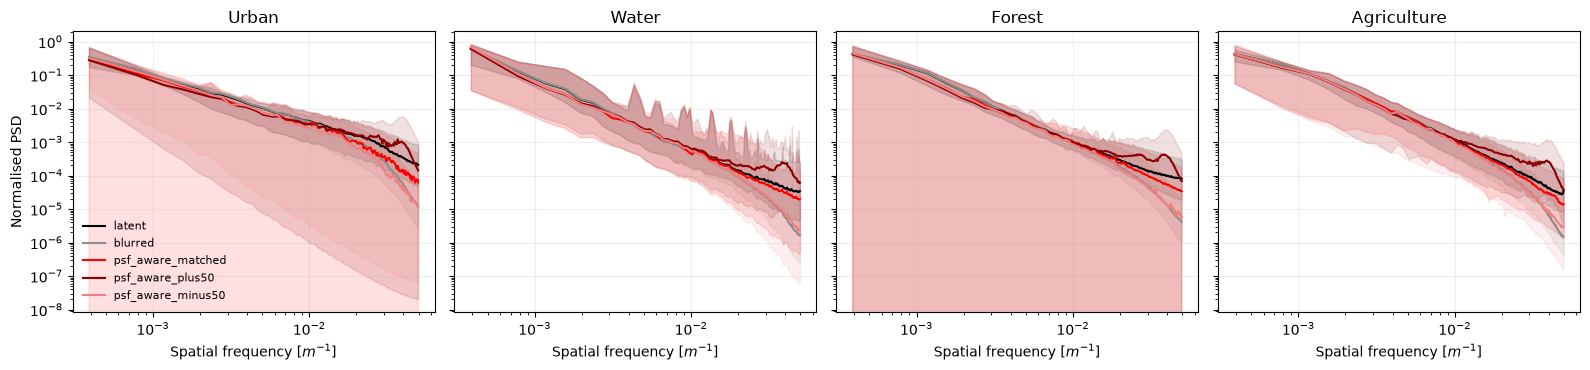

In [14]:
def load_spectral_records(manifest):
    records = []
    for patch in manifest.itertuples(index=False):
        _, spectra_path = patch_cache_paths(patch.patch_id)
        if not spectra_path.exists():
            continue
        spectra = dict(np.load(spectra_path))
        frequency = spectra.pop("frequency_m_inv")
        for curve, values in spectra.items():
            for f, value in zip(frequency, values):
                records.append({
                    "patch_id": patch.patch_id,
                    "scene_class": patch.scene_class,
                    "region_id": patch.region_id,
                    "abs_latitude_band": patch.abs_latitude_band,
                    "curve": curve,
                    "frequency_m_inv": float(f),
                    "value": float(value),
                })
    return pd.DataFrame(records)


def plot_spectral_bands(spectral_frame):
    if spectral_frame.empty:
        print("No cached spectra available.")
        return None
    region_spectra = (
        spectral_frame.groupby(
            ["scene_class", "region_id", "curve", "frequency_m_inv"],
            observed=True,
        )["value"].mean().reset_index()
    )
    curves = [
        "psd_latent", "psd_blurred", "psd_psf_aware_matched",
        "psd_psf_aware_plus50", "psd_psf_aware_minus50",
    ]
    colors = {
        "psd_latent": "black",
        "psd_blurred": "0.55",
        "psd_psf_aware_matched": "red",
        "psd_psf_aware_plus50": "darkred",
        "psd_psf_aware_minus50": "lightcoral",
    }
    fig, axes = plt.subplots(1, 4, figsize=(16, 3.8), sharey=True)
    for axis, scene_class in zip(axes, ["urban", "water", "forest", "agriculture"]):
        subset = region_spectra[region_spectra["scene_class"] == scene_class]
        for curve in curves:
            curve_data = subset[subset["curve"] == curve]
            if curve_data.empty:
                continue
            matrix = curve_data.pivot_table(
                index="region_id", columns="frequency_m_inv",
                values="value", aggfunc="mean"
            )
            frequency = matrix.columns.to_numpy(dtype=float)
            values = matrix.to_numpy(dtype=float)
            centre = np.nanmedian(values, axis=0)
            low, high = np.nanquantile(values, [0.025, 0.975], axis=0)
            axis.loglog(frequency, centre, color=colors[curve], label=curve[4:])
            axis.fill_between(frequency, low, high, color=colors[curve], alpha=0.12)
        axis.set_title(scene_class.capitalize())
        axis.set_xlabel(r"Spatial frequency [$m^{-1}$]")
        axis.grid(alpha=0.2)
    axes[0].set_ylabel("Normalised PSD")
    axes[0].legend(frameon=False, fontsize=8)
    fig.tight_layout()
    output = FIGURE_DIR / "multi_patch_spectral_uncertainty.pdf"
    fig.savefig(output, bbox_inches="tight")
    return fig


spectral_records = load_spectral_records(patch_manifest)
if not spectral_records.empty:
    spectral_records.to_csv(
        TABLE_DIR / "multi_patch_spectral_records.csv", index=False
    )
    spectral_figure = plot_spectral_bands(spectral_records)

## 7. Production-run quality gates

These checks must pass before any aggregate number is transferred to the paper.
A complete run has 360 patches and seven method rows per patch. Every scene class
must contain ten independent regions and every included region nine patches.

In [15]:
def validate_production_outputs(metric_frame, failure_frame):
    expected_patches = len(patch_manifest)
    expected_rows = expected_patches * len(METRIC_METHODS)
    checks = {
        "no_failures": failure_frame.empty,
        "metric_row_count": len(metric_frame) == expected_rows,
        "patch_count": metric_frame["patch_id"].nunique() == expected_patches,
        "method_count": metric_frame["method"].nunique() == len(METRIC_METHODS),
        "finite_rmse": np.isfinite(metric_frame["rmse_vs_latent"]).all(),
        "positive_degradation": (metric_frame["rmse_psf_degradation"] > 0).all(),
        "ten_regions_per_class": (
            metric_frame.groupby("scene_class")["region_id"].nunique() == 10
        ).all(),
        "nine_patches_per_region": (
            metric_frame[["region_id", "patch_id"]].drop_duplicates()
            .groupby("region_id")["patch_id"].nunique() == 9
        ).all(),
    }
    report = pd.Series(checks, name="passed")
    display(report)
    if not report.all():
        failed = report.index[~report].tolist()
        raise AssertionError(f"Production validation failed: {failed}")
    return report


def validate_benchmark_outputs(metric_frame, benchmark_frame):
    expected_patches = len(patch_manifest)
    expected_timed = max(0, expected_patches - BENCHMARK_WARMUP_PATCHES)
    required_metric_columns = {
        "operator_build_s", "solve_s", "projection_s",
        "runtime_s", "method_total_s", "operator_nnz",
        "benchmark_included",
    }
    required_patch_columns = {
        "patch_execution_status", "benchmark_included",
        "synthetic_build_s", "spectral_analysis_s",
        "checkpoint_write_s", "cleanup_s", "patch_wall_s",
        "operator_nnz_total", "healpix_cells_max", "peak_rss_mib",
    }
    has_columns = (
        required_metric_columns.issubset(metric_frame.columns)
        and required_patch_columns.issubset(benchmark_frame.columns)
    )
    checks = {"benchmark_columns_present": has_columns}
    if has_columns:
        timed_patches = benchmark_frame[
            benchmark_frame["benchmark_included"].fillna(False)
        ]
        timed_metrics = metric_frame[metric_frame["benchmark_included"].fillna(False)]
        timing_columns = [
            "operator_build_s", "solve_s", "projection_s", "method_total_s"
        ]
        timed_psf = timed_metrics[timed_metrics["method"].str.startswith("psf_aware")]
        checks.update({
            "one_benchmark_row_per_patch": len(benchmark_frame) == expected_patches,
            "all_patches_recomputed": (
                benchmark_frame["patch_execution_status"] == "computed"
            ).all(),
            "warmup_exclusion_correct": (
                timed_patches["patch_id"].nunique() == expected_timed
            ),
            "finite_nonnegative_method_timings": (
                np.isfinite(timed_metrics[timing_columns]).all().all()
                and (timed_metrics[timing_columns] >= 0).all().all()
            ),
            "finite_positive_patch_wall_time": (
                np.isfinite(timed_patches["patch_wall_s"]).all()
                and (timed_patches["patch_wall_s"] > 0).all()
            ),
            "positive_sparse_operator_size": (
                np.isfinite(timed_psf["operator_nnz"]).all()
                and (timed_psf["operator_nnz"] > 0).all()
            ),
            "peak_ram_recorded": (
                np.isfinite(timed_patches["peak_rss_mib"]).all()
                and (timed_patches["peak_rss_mib"] > 0).all()
            ),
            "peak_vram_recorded_when_cuda": (
                not DEVICE.startswith("cuda")
                or (
                    np.isfinite(timed_patches["peak_gpu_memory_mib"]).all()
                    and (timed_patches["peak_gpu_memory_mib"] > 0).all()
                )
            ),
        })
    report = pd.Series(checks, name="passed")
    display(report)
    if FORCE_RECOMPUTE_METRICS_FOR_BENCHMARK and not report.all():
        failed = report.index[~report].tolist()
        raise AssertionError(f"Compute benchmark validation failed: {failed}")
    return report


if RUN_FULL_EXPERIMENT:
    production_checks = validate_production_outputs(metrics, failures)
    benchmark_checks = validate_benchmark_outputs(metrics, benchmark)
else:
    print("Quality gates will run automatically after the full experiment.")

no_failures                False
metric_row_count           False
patch_count                False
method_count                True
finite_rmse                 True
positive_degradation        True
ten_regions_per_class       True
nine_patches_per_region    False
Name: passed, dtype: bool

AssertionError: Production validation failed: ['no_failures', 'metric_row_count', 'patch_count', 'nine_patches_per_region']

## Reporting guidance

For the manuscript, report the number of independent regions as the primary
sample size (`n = 10` per class), while also stating that each region contributes
nine non-overlapping patches (`360` patches total). Do not describe all 360
patches as independent observations.

Recommended paper table columns:

1. scene class and method;
2. number of independent regions and number of patches;
3. region-mean RMSE ± between-region standard deviation;
4. cluster-bootstrap 95% interval;
5. mean recovery fraction;
6. matched-method win fraction in paired patch comparisons.

Before submission, inspect `multi_patch_latitude_failures.csv`, the site contact
sheet, and the latitude-stratified table. If a region is heterogeneous or
mislabeled, change its `include` flag or label and rerun the complete region;
never remove individual patches because their results are unfavourable.

### Compute benchmark

For the publication benchmark, keep `FORCE_RECOMPUTE_METRICS_FOR_BENCHMARK=True`.
This recomputes the resampling methods while retaining each expensive Esri scene in
its persistent Zarr cache. CUDA is synchronized around operator construction and
inversion. The first actually computed patch is excluded as a warm-up; metric-cache
hits are never included in timing summaries.

Report the hardware and software fields from `multi_patch_run_summary.csv`, the
median and interquartile range from `multi_patch_runtime_by_method.csv`, and the
effective throughput in patches per hour. The method table also reports operator
`nnz`, density, `Npt`, and retained HEALPix-cell counts.
`multi_patch_runtime_scaling.csv` shows cumulative cost and throughput convergence
from one patch up to the complete run. `multi_patch_runtime_stages.csv` separates
Esri/Zarr loading, synthetic-scene construction, spectral analysis, checkpoint I/O,
explicit memory cleanup,
total patch wall time, GPU peak allocation, and process RSS before/after cleanup.
`multi_patch_runtime_by_patch.csv` is the audit trail used
to detect cache hits, warm-up exclusions, and heterogeneous runtimes. After the final
benchmark has been archived, set the force switch back to `False` for fast restarts.